In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
marketing = pd.read_csv("../data/raw/marketing_campaigns.csv")
customers = pd.read_csv("../data/raw/customers.csv")
orders = pd.read_csv("../data/raw/orders.csv")

print("Datasets loaded successfully!")

print("\nMARKETING COLUMNS:")
print(marketing.columns.tolist())

print("\nMarketing Shape:", marketing.shape)

marketing.head()

Datasets loaded successfully!

MARKETING COLUMNS:
['campaign_id', 'campaign_name', 'channel', 'campaign_date', 'spend', 'impressions', 'clicks', 'leads', 'conversions']

Marketing Shape: (200, 9)


,campaign_id,campaign_name,channel,campaign_date,spend,impressions,clicks,leads,conversions
0,M1000,Referral Campaign 1,Referral,2026-01-20,177948.19,456395,16665,5034,977
1,M1001,Email Campaign 2,Email,2026-05-27,48246.98,568772,19725,2095,278
2,M1002,YouTube Campaign 3,YouTube,2025-06-02,61800.92,570784,7931,1329,370
3,M1003,Referral Campaign 4,Referral,2025-03-15,175759.61,71119,1316,413,60
4,M1004,Email Campaign 5,Email,2025-04-14,187673.54,584163,16594,3743,269


In [2]:
# Create a copy for marketing analysis
marketing_analysis = marketing.copy()

# Calculate Click Through Rate
marketing_analysis["CTR_%"] = (
    marketing_analysis["clicks"]
    / marketing_analysis["impressions"]
) * 100

# Calculate Cost Per Click
marketing_analysis["CPC"] = (
    marketing_analysis["spend"]
    / marketing_analysis["clicks"]
)

# Calculate Lead Conversion Rate
marketing_analysis["Lead_Conversion_Rate_%"] = (
    marketing_analysis["leads"]
    / marketing_analysis["clicks"]
) * 100

# Calculate Conversion Rate
marketing_analysis["Conversion_Rate_%"] = (
    marketing_analysis["conversions"]
    / marketing_analysis["clicks"]
) * 100

# Calculate Cost Per Lead
marketing_analysis["CPL"] = (
    marketing_analysis["spend"]
    / marketing_analysis["leads"]
)

# Calculate Cost Per Conversion
marketing_analysis["Cost_Per_Conversion"] = (
    marketing_analysis["spend"]
    / marketing_analysis["conversions"]
)

print("Marketing performance metrics calculated successfully!")

marketing_analysis.head()

Marketing performance metrics calculated successfully!


,campaign_id,campaign_name,channel,campaign_date,spend,impressions,clicks,leads,conversions,CTR_%,CPC,Lead_Conversion_Rate_%,Conversion_Rate_%,CPL,Cost_Per_Conversion
0,M1000,Referral Campaign 1,Referral,2026-01-20,177948.19,456395,16665,5034,977,3.651442,10.677959,30.207021,5.862586,35.349263,182.137349
1,M1001,Email Campaign 2,Email,2026-05-27,48246.98,568772,19725,2095,278,3.467998,2.445981,10.621039,1.409379,23.029585,173.550288
2,M1002,YouTube Campaign 3,YouTube,2025-06-02,61800.92,570784,7931,1329,370,1.389492,7.792324,16.757029,4.665238,46.501821,167.029514
3,M1003,Referral Campaign 4,Referral,2025-03-15,175759.61,71119,1316,413,60,1.850420,133.555935,31.382979,4.559271,425.568063,2929.326833
4,M1004,Email Campaign 5,Email,2025-04-14,187673.54,584163,16594,3743,269,2.840646,11.309723,22.556346,1.621068,50.139872,697.671152


In [3]:
# Create a copy for marketing analysis
marketing_analysis = marketing.copy()

# Calculate Click Through Rate
marketing_analysis["CTR_%"] = (
    marketing_analysis["clicks"]
    / marketing_analysis["impressions"]
) * 100

# Calculate Cost Per Click
marketing_analysis["CPC"] = (
    marketing_analysis["spend"]
    / marketing_analysis["clicks"]
)

# Calculate Lead Conversion Rate
marketing_analysis["Lead_Conversion_Rate_%"] = (
    marketing_analysis["leads"]
    / marketing_analysis["clicks"]
) * 100

# Calculate Conversion Rate
marketing_analysis["Conversion_Rate_%"] = (
    marketing_analysis["conversions"]
    / marketing_analysis["clicks"]
) * 100

# Calculate Cost Per Lead
marketing_analysis["CPL"] = (
    marketing_analysis["spend"]
    / marketing_analysis["leads"]
)

# Calculate Cost Per Conversion
marketing_analysis["Cost_Per_Conversion"] = (
    marketing_analysis["spend"]
    / marketing_analysis["conversions"]
)

print("Marketing performance metrics calculated successfully!")

marketing_analysis.head()





Marketing performance metrics calculated successfully!


,campaign_id,campaign_name,channel,campaign_date,spend,impressions,clicks,leads,conversions,CTR_%,CPC,Lead_Conversion_Rate_%,Conversion_Rate_%,CPL,Cost_Per_Conversion
0,M1000,Referral Campaign 1,Referral,2026-01-20,177948.19,456395,16665,5034,977,3.651442,10.677959,30.207021,5.862586,35.349263,182.137349
1,M1001,Email Campaign 2,Email,2026-05-27,48246.98,568772,19725,2095,278,3.467998,2.445981,10.621039,1.409379,23.029585,173.550288
2,M1002,YouTube Campaign 3,YouTube,2025-06-02,61800.92,570784,7931,1329,370,1.389492,7.792324,16.757029,4.665238,46.501821,167.029514
3,M1003,Referral Campaign 4,Referral,2025-03-15,175759.61,71119,1316,413,60,1.850420,133.555935,31.382979,4.559271,425.568063,2929.326833
4,M1004,Email Campaign 5,Email,2025-04-14,187673.54,584163,16594,3743,269,2.840646,11.309723,22.556346,1.621068,50.139872,697.671152


In [4]:
channel_performance = (
    marketing_analysis
    .groupby("channel")
    .agg(
        Total_Spend=("spend", "sum"),
        Total_Impressions=("impressions", "sum"),
        Total_Clicks=("clicks", "sum"),
        Total_Leads=("leads", "sum"),
        Total_Conversions=("conversions", "sum")
    )
)

# Calculate channel-level metrics

channel_performance["CTR_%"] = (
    channel_performance["Total_Clicks"]
    / channel_performance["Total_Impressions"]
) * 100

channel_performance["CPC"] = (
    channel_performance["Total_Spend"]
    / channel_performance["Total_Clicks"]
)

channel_performance["Conversion_Rate_%"] = (
    channel_performance["Total_Conversions"]
    / channel_performance["Total_Clicks"]
) * 100

channel_performance["Cost_Per_Conversion"] = (
    channel_performance["Total_Spend"]
    / channel_performance["Total_Conversions"]
)

# Sort by conversions
channel_performance = channel_performance.sort_values(
    "Total_Conversions",
    ascending=False
)

print("MARKETING CHANNEL PERFORMANCE")
print("=" * 80)

channel_performance

MARKETING CHANNEL PERFORMANCE


,Total_Spend,Total_Impressions,Total_Clicks,Total_Leads,Total_Conversions,CTR_%,CPC,Conversion_Rate_%,Cost_Per_Conversion
channel,,,,,,,,,
Google Ads,5078358.47,22017163,1154298,235061,37564,5.242719,4.399521,3.254272,135.192165
Instagram,5016067.96,23529002,1131070,185143,35514,4.807131,4.434799,3.139859,141.241988
Email,4766099.17,22287223,988892,192671,31267,4.437036,4.819636,3.161822,152.432250
YouTube,3850029.10,17572005,728251,143089,26120,4.144382,5.286679,3.586675,147.397745
Referral,3102154.63,14128919,669056,135214,24285,4.735366,4.636614,3.629741,127.739536


In [5]:
channel_score = channel_performance.copy()

# Higher conversions = better
channel_score["Conversion_Score"] = (
    channel_score["Total_Conversions"]
    / channel_score["Total_Conversions"].max()
) * 100


# Higher CTR = better
channel_score["CTR_Score"] = (
    channel_score["CTR_%"]
    / channel_score["CTR_%"].max()
) * 100


# Higher conversion rate = better
channel_score["Conversion_Rate_Score"] = (
    channel_score["Conversion_Rate_%"]
    / channel_score["Conversion_Rate_%"].max()
) * 100


# Lower Cost Per Conversion = better
channel_score["Cost_Efficiency_Score"] = (
    channel_score["Cost_Per_Conversion"].min()
    / channel_score["Cost_Per_Conversion"]
) * 100


# Final Marketing Performance Score
channel_score["Marketing_Performance_Score"] = (
    channel_score["Conversion_Score"] * 0.35
    + channel_score["CTR_Score"] * 0.20
    + channel_score["Conversion_Rate_Score"] * 0.25
    + channel_score["Cost_Efficiency_Score"] * 0.20
)


# Sort from best to worst
channel_score = channel_score.sort_values(
    "Marketing_Performance_Score",
    ascending=False
)

print("MARKETING CHANNEL PERFORMANCE SCORE")
print("=" * 80)

channel_score[
    [
        "Total_Spend",
        "Total_Conversions",
        "CTR_%",
        "Conversion_Rate_%",
        "Cost_Per_Conversion",
        "Marketing_Performance_Score"
    ]
]

MARKETING CHANNEL PERFORMANCE SCORE


,Total_Spend,Total_Conversions,CTR_%,Conversion_Rate_%,Cost_Per_Conversion,Marketing_Performance_Score
channel,,,,,,
Google Ads,5078358.47,37564,5.242719,3.254272,135.192165,96.311419
Instagram,5016067.96,35514,4.807131,3.139859,141.241988,91.142194
Referral,3102154.63,24285,4.735366,3.629741,127.739536,85.691924
Email,4766099.17,31267,4.437036,3.161822,152.432250,84.596636
YouTube,3850029.10,26120,4.144382,3.586675,147.397745,82.183194


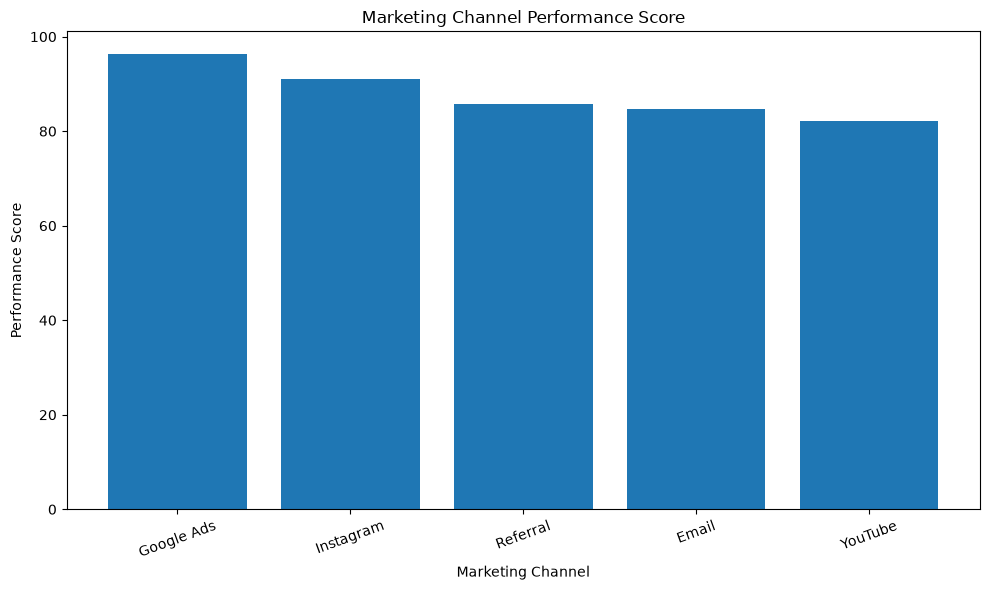

In [6]:
plt.figure(figsize=(10, 6))

plt.bar(
    channel_score.index,
    channel_score["Marketing_Performance_Score"]
)

plt.title("Marketing Channel Performance Score")

plt.xlabel("Marketing Channel")

plt.ylabel("Performance Score")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [7]:
best_channel = channel_score.index[0]
best_score = channel_score.iloc[0]["Marketing_Performance_Score"]

worst_channel = channel_score.index[-1]
worst_score = channel_score.iloc[-1]["Marketing_Performance_Score"]

print("BEST MARKETING CHANNEL")
print("=" * 50)
print(f"Channel: {best_channel}")
print(f"Performance Score: {best_score:.2f}")

print("\nWORST MARKETING CHANNEL")
print("=" * 50)
print(f"Channel: {worst_channel}")
print(f"Performance Score: {worst_score:.2f}")

BEST MARKETING CHANNEL
Channel: Google Ads
Performance Score: 96.31

WORST MARKETING CHANNEL
Channel: YouTube
Performance Score: 82.18


In [8]:
# Top 10 campaigns based on conversions

top_campaigns = (
    marketing_analysis
    .sort_values("conversions", ascending=False)
    .head(10)
)

print("TOP 10 MARKETING CAMPAIGNS BY CONVERSIONS")
print("=" * 80)

top_campaigns[
    [
        "campaign_name",
        "channel",
        "spend",
        "impressions",
        "clicks",
        "leads",
        "conversions",
        "Conversion_Rate_%",
        "Cost_Per_Conversion"
    ]
]


TOP 10 MARKETING CAMPAIGNS BY CONVERSIONS


,campaign_name,channel,spend,impressions,clicks,leads,conversions,Conversion_Rate_%,Cost_Per_Conversion
162,Email Campaign 163,Email,72494.65,895173,42116,14296,4016,9.535568,18.051457
64,Referral Campaign 65,Referral,52312.57,966981,45430,14203,3849,8.472375,13.591211
166,YouTube Campaign 167,YouTube,189116.33,848321,58227,17365,3755,6.448898,50.363870
153,Instagram Campaign 154,Instagram,191399.78,941435,37064,12617,3708,10.004317,51.618064
136,Instagram Campaign 137,Instagram,149990.58,990583,76256,12503,3545,4.648815,42.310460
181,Google Ads Campaign 182,Google Ads,178669.52,775116,51943,17492,3314,6.380070,53.913555
80,Referral Campaign 81,Referral,37513.18,672679,50407,11246,3029,6.009086,12.384675
115,Email Campaign 116,Email,182815.97,924338,40905,12372,3008,7.353624,60.776586
46,Referral Campaign 47,Referral,85215.91,756848,50852,12101,2964,5.828679,28.750307
128,Instagram Campaign 129,Instagram,62641.76,560101,42192,10275,2606,6.176526,24.037513


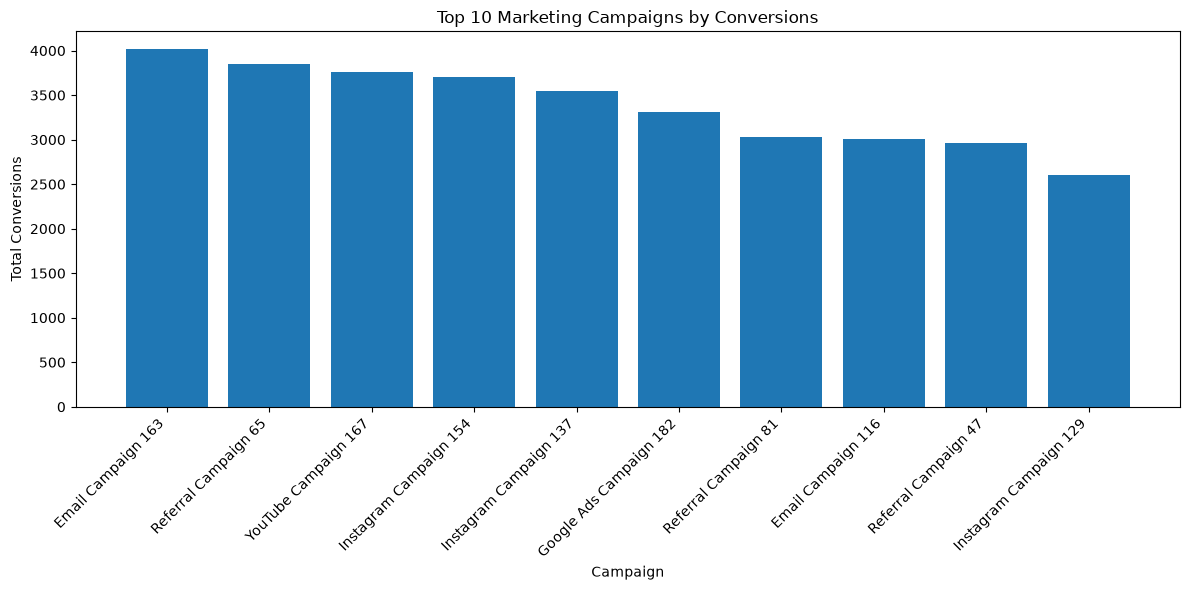

In [9]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_campaigns["campaign_name"],
    top_campaigns["conversions"]
)

plt.title("Top 10 Marketing Campaigns by Conversions")

plt.xlabel("Campaign")

plt.ylabel("Total Conversions")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()